In [1]:
# --! include root folder into PYTHONPATH --!

import os
import sys

curr_dir = os.getcwd()
example_dir = os.path.abspath(os.path.join(curr_dir, '..'))
sys.path.append(example_dir)
root_dir = os.path.abspath(os.path.join(curr_dir, '..', '..', '..'))
sys.path.append(root_dir)

# --! import Python libraries --!

import torch
import numpy as np
import matplotlib.pyplot as plt

import kind
import example_mujoco
import util_data
import util_nn

data_dir = '../../../data/mujoco/hopper'
model_dir = '../../../models/mujoco/hopper'
result_dir = '../../../results/mujoco/hopper'

In [2]:
# --! specify kind arguments --!

parser = kind.create_args_parser()

args = parser.parse_args(
    args=[
        '--file_dir', data_dir,
        '--file_name', 'hopper',
        '--data_nsample_baseline', '918',
        '--data_nsample_nom', '48',
        '--data_nsample_exc', '48',
        '--obs_ndim', '11',
        '--act_ndim', '3',
        '--target_ndim', '11',
        '--data_train_size', '0.8',

        '--back_nsample', '32',
        '--fore_nsample', '16',

        '--batch_size', '256',
        '--learning_rate', '0.001',
        '--weight_decay', '0.000001',
        '--nepoch', '500',
        '--patience', '50',
        '--checkpoints', model_dir,

        '--rez_nsample_nom', '16',
        '--rez_nsample_exc', '8',
        '--embed_nom', '{"sin": 6, "cos": 6}',
        '--embed_exc', '{"data": 12}',
    ]
)

setpoint = torch.zeros(args.target_ndim)

In [3]:
# --! initialize random seed

seeds = [3, 123, 2026, 8192, 65536]
seed = seeds[0]

util_nn.set_seed(seed)

print(f'setting seed {seed}')

setting seed 3


In [4]:
# --! create model, dataset and training

model = kind.model(args)
dataset = example_mujoco.dataset(args, setpoint, load_normalized=True, extract_windows=False)
training = kind.training(model)

In [5]:
# --! compute model capacity

nparam = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'number of trainable parameters: {nparam/1e6}M')

number of trainable parameters: 1.226524M


### Train nominal model

In [6]:
model.train()
training.fit(dataset)

>>> training nominal mean >>>
	epoch 1 losses: train=0.479518, valid=0.164474, test=0.163392
	validation loss decreased (inf -> 0.164474), saving model ...
	epoch 2 losses: train=0.109935, valid=0.068379, test=0.067591
	validation loss decreased (0.164474 -> 0.068379), saving model ...
	epoch 3 losses: train=0.053702, valid=0.044341, test=0.043907
	validation loss decreased (0.068379 -> 0.044341), saving model ...
	epoch 4 losses: train=0.038665, valid=0.032946, test=0.032742
	validation loss decreased (0.044341 -> 0.032946), saving model ...
	epoch 5 losses: train=0.029035, valid=0.025507, test=0.025313
	validation loss decreased (0.032946 -> 0.025507), saving model ...
	epoch 6 losses: train=0.023090, valid=0.020693, test=0.020496
	validation loss decreased (0.025507 -> 0.020693), saving model ...
	epoch 7 losses: train=0.018854, valid=0.017189, test=0.017075
	validation loss decreased (0.020693 -> 0.017189), saving model ...
	epoch 8 losses: train=0.016229, valid=0.015163, test=0.01

In [8]:
model.eval()
data_loader, _, _ = dataset.load(data_type='nom')

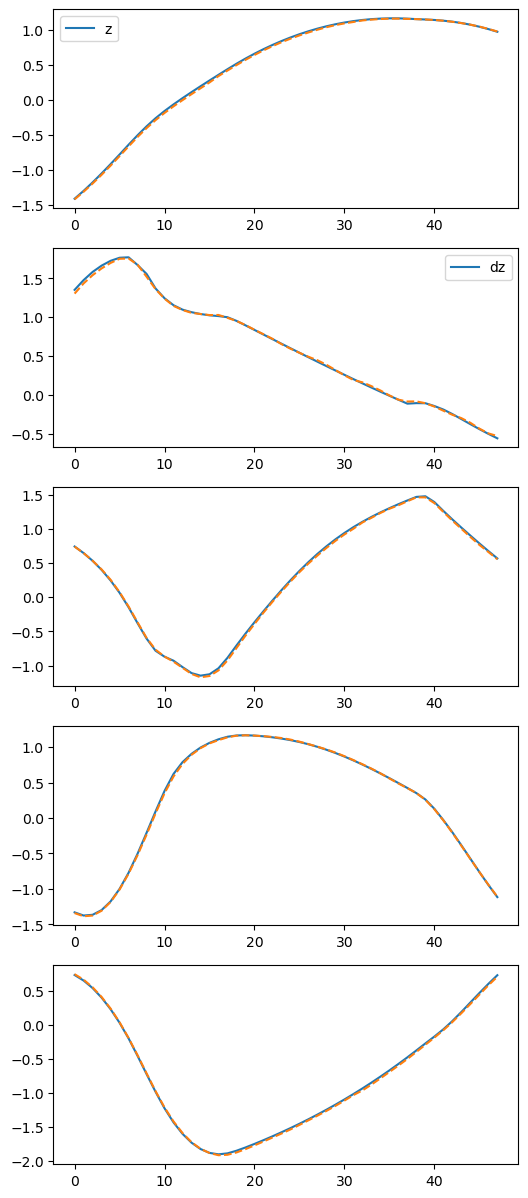

In [11]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom

        plt.figure(figsize=(6,15))

        plt.subplot(5,1,1)
        plt.plot(true[jdata, :, :1], label='z')
        plt.plot(mean_nom[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(5,1,2)
        plt.plot(true[jdata, :, 6], label='dz')
        plt.plot(mean_nom[0, :, 6], linestyle='dashed')
        plt.legend()

        plt.subplot(5,1,3)
        plt.plot(true[jdata, :, 1])
        plt.plot(mean_nom[0, :, 1], linestyle='dashed')

        plt.subplot(5,1,4)
        plt.plot(true[jdata, :, 2])
        plt.plot(mean_nom[0, :, 2], linestyle='dashed')

        plt.subplot(5,1,5)
        plt.plot(true[jdata, :, 3])
        plt.plot(mean_nom[0, :, 3], linestyle='dashed')

        plt.show()

        break

### Train nominal uncertainty

In [12]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training nominal uncertainty >>>
	epoch 1 losses: train=0.069183, valid=0.038550, test=0.038543
	validation loss decreased (inf -> 0.038550), saving model ...
	epoch 2 losses: train=0.026019, valid=0.018602, test=0.018022
	validation loss decreased (0.038550 -> 0.018602), saving model ...
	epoch 3 losses: train=0.014604, valid=0.013274, test=0.012921
	validation loss decreased (0.018602 -> 0.013274), saving model ...
	epoch 4 losses: train=0.011631, valid=0.010878, test=0.010571
	validation loss decreased (0.013274 -> 0.010878), saving model ...
	epoch 5 losses: train=0.009764, valid=0.009970, test=0.009684
	validation loss decreased (0.010878 -> 0.009970), saving model ...
	epoch 6 losses: train=0.008299, valid=0.008163, test=0.007913
	validation loss decreased (0.009970 -> 0.008163), saving model ...
	epoch 7 losses: train=0.007471, valid=0.007508, test=0.007302
	validation loss decreased (0.008163 -> 0.007508), saving model ...
	epoch 8 losses: train=0.007019, valid=0.007018, te

In [13]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

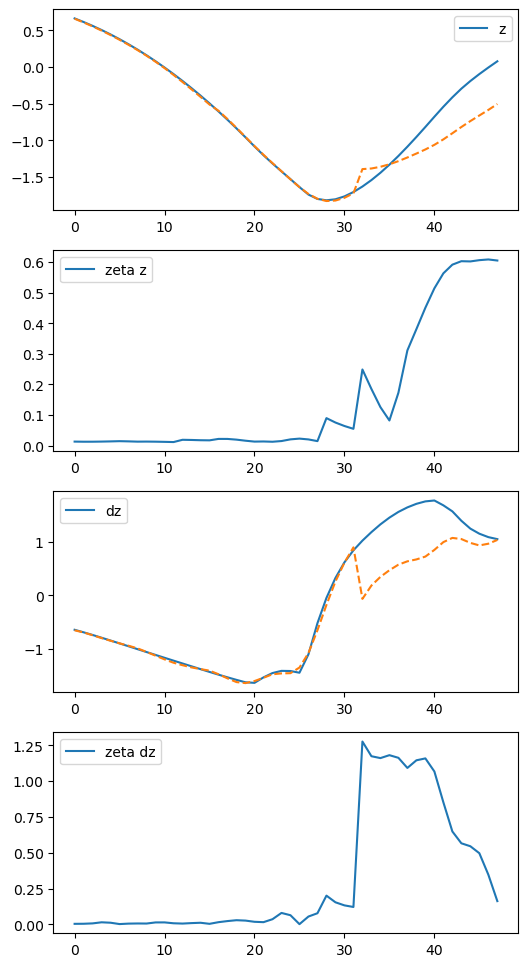

In [15]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_nom = model_o.mean_nom
        zeta_nom = model_o.zeta_nom

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(mean_nom[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(zeta_nom[0, :, :1], label='zeta z')
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(truth[jdata, :, 6], label='dz')
        plt.plot(mean_nom[0, :, 6], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(zeta_nom[0, :, 6], label='zeta dz')
        plt.legend()

        plt.show()

        break

### Train excursion model

In [16]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion mean >>>
	epoch 1 losses: train=0.869368, valid=0.690792, test=0.684758
	validation loss decreased (inf -> 0.690792), saving model ...
	epoch 2 losses: train=0.396565, valid=0.235218, test=0.240699
	validation loss decreased (0.690792 -> 0.235218), saving model ...
	epoch 3 losses: train=0.175855, valid=0.128314, test=0.130666
	validation loss decreased (0.235218 -> 0.128314), saving model ...
	epoch 4 losses: train=0.116248, valid=0.098750, test=0.099914
	validation loss decreased (0.128314 -> 0.098750), saving model ...
	epoch 5 losses: train=0.090417, valid=0.077827, test=0.077705
	validation loss decreased (0.098750 -> 0.077827), saving model ...
	epoch 6 losses: train=0.069353, valid=0.058829, test=0.058091
	validation loss decreased (0.077827 -> 0.058829), saving model ...
	epoch 7 losses: train=0.053896, valid=0.047409, test=0.046704
	validation loss decreased (0.058829 -> 0.047409), saving model ...
	epoch 8 losses: train=0.044741, valid=0.040247, test=0.

In [17]:
model.eval()
_, _, data_loader = dataset.load(data_type='exc')

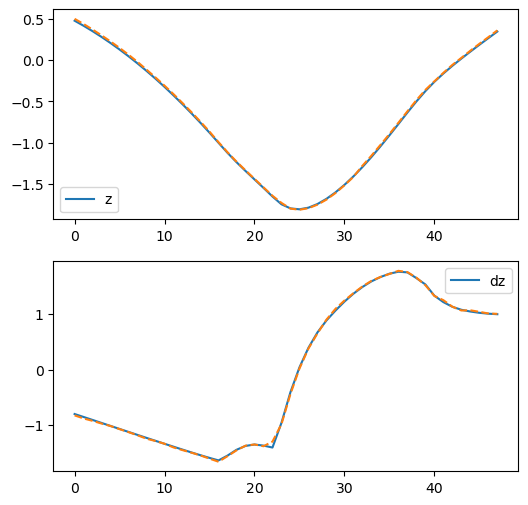

In [19]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_exc = model_o.mean_exc

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(mean_exc[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(2,1,2)
        plt.plot(truth[jdata, :, 6], label='dz')
        plt.plot(mean_exc[0, :, 6], linestyle='dashed')
        plt.legend()

        plt.show()

        break

### Train excursion uncertainty

In [20]:
model.train()
training.fit_next()
training.fit(dataset)

>>> training excursion uncertainty >>>
	epoch 1 losses: train=0.222443, valid=0.100528, test=0.099345
	validation loss decreased (inf -> 0.100528), saving model ...
	epoch 2 losses: train=0.079485, valid=0.064314, test=0.063552
	validation loss decreased (0.100528 -> 0.064314), saving model ...
	epoch 3 losses: train=0.056524, valid=0.049001, test=0.048311
	validation loss decreased (0.064314 -> 0.049001), saving model ...
	epoch 4 losses: train=0.043822, valid=0.039484, test=0.038764
	validation loss decreased (0.049001 -> 0.039484), saving model ...
	epoch 5 losses: train=0.037310, valid=0.034253, test=0.033563
	validation loss decreased (0.039484 -> 0.034253), saving model ...
	epoch 6 losses: train=0.032729, valid=0.034783, test=0.034133
	early stopping counter: 1 out of 50
	epoch 7 losses: train=0.029510, valid=0.027877, test=0.027300
	validation loss decreased (0.034253 -> 0.027877), saving model ...
	epoch 8 losses: train=0.026328, valid=0.025390, test=0.024912
	validation loss 

In [21]:
model.eval()
_, _, data_loader = dataset.load(data_type='mixed')

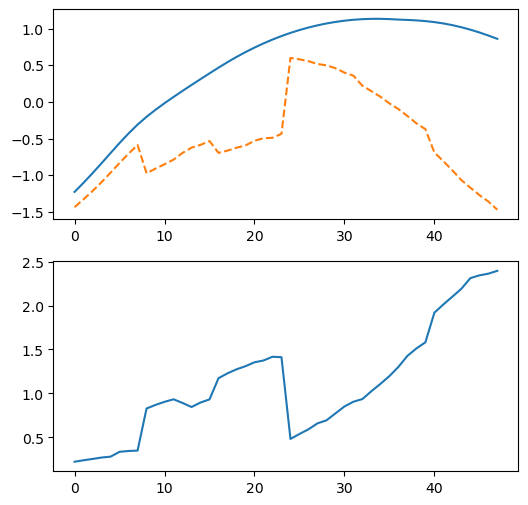

In [25]:
jdata = 2

with torch.no_grad():
    for back, fore in data_loader:
        true = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        mean_exc = model_o.mean_exc
        zeta_exc = model_o.zeta_exc

        plt.figure(figsize=(6,6))

        plt.subplot(2,1,1)
        plt.plot(true[jdata, :, :1])
        plt.plot(mean_exc[0, :, :1], linestyle='dashed')

        plt.subplot(2,1,2)
        plt.plot(zeta_exc[0, :, :1])

        plt.show()

        break

## Evaluate KIND blending

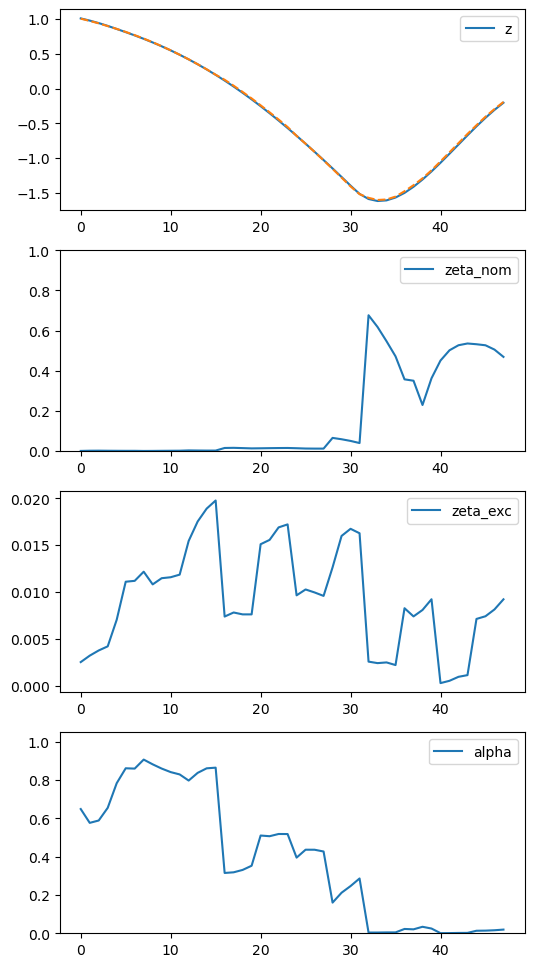

In [27]:
jdata = 1

with torch.no_grad():
    for back, fore in data_loader:
        truth = torch.cat([back, fore], dim=1)

        model_o = model(back[[jdata]])
        pred = model_o.blend
        zeta_nom = model_o.zeta_nom
        zeta_exc = model_o.zeta_exc
        alpha = model_o.alpha

        plt.figure(figsize=(6,12))

        plt.subplot(4,1,1)
        plt.plot(truth[jdata, :, :1], label='z')
        plt.plot(pred[0, :, :1], linestyle='dashed')
        plt.legend()

        plt.subplot(4,1,2)
        plt.plot(zeta_nom[0, :, :1], label='zeta_nom')
        plt.ylim((0,1))
        plt.legend()

        plt.subplot(4,1,3)
        plt.plot(zeta_exc[0, :, :1], label='zeta_exc')
        plt.legend()

        plt.subplot(4,1,4)
        plt.plot(alpha[0, :, :1], label='alpha')
        plt.ylim((0.0, 1.05))
        plt.legend()

        plt.show()

        break